In [1]:
import sys
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from ahrs.filters import EKF
from scipy.spatial.transform import Rotation as R

sys.path.append("/app/")

from src.utils import BaseGeometryTransformer

In [2]:
voxl_imu0 = pd.read_csv("/app/data/UAV/log0001/run/mpa/imu0/data.csv")
voxl_imu1 = pd.read_csv("/app/data/UAV/log0001/run/mpa/imu1/data.csv")
px4_imu0 = pd.read_csv("/app/data/UAV/log0001/px4/imu_combined/log0001_px4_imu0_combined.csv")
px4_imu1 = pd.read_csv("/app/data/UAV/log0001/px4/imu_combined/log0001_px4_imu1_combined.csv")

actuator_motor = pd.read_csv("/app/data/UAV/log0001/px4/09_00_22_actuator_motors_0.csv")
actuator_output = pd.read_csv("/app/data/UAV/log0001/px4/09_00_22_actuator_outputs_1.csv")

gps_raw = pd.read_csv("/app/data/UAV/log0001/px4/09_00_22_sensor_gps_0.csv")

acc_col = ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)']
gyr_col = ['GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)']
gps_lla = ['lon', 'lat', 'alt']
gps_ned = ['north', 'east', 'down']
control_col = ['control[0]', 'control[1]', 'control[2]', 'control[3]']

In [3]:
voxl_imu0['timestamp'] = voxl_imu0['timestamp(ns)'] / 1e3
voxl_imu1['timestamp'] = voxl_imu1['timestamp(ns)'] / 1e3

voxl_imu0 = voxl_imu0[voxl_imu0.columns[2:]]
voxl_imu1 = voxl_imu1[voxl_imu1.columns[2:]]
px4_imu0 = px4_imu0[px4_imu0.columns[1:]]
px4_imu1 = px4_imu1[px4_imu1.columns[1:]]

gps_raw = gps_raw[['timestamp', 'lon', 'lat', 'alt']]

actuator_motor = actuator_motor[['timestamp', 'control[0]', 'control[1]', 'control[2]', 'control[3]']]
actuator_output = actuator_output[['timestamp', 'output[0]', 'output[1]', 'output[2]', 'output[3]']]


px4_imu0_timestamp = (px4_imu0['timestamp'].iloc[0], px4_imu0['timestamp'].iloc[-1])

timestamp_filter = voxl_imu0['timestamp'] > px4_imu0_timestamp[0]
timestamp_filter &= voxl_imu0['timestamp'] <= px4_imu0_timestamp[1]
voxl_imu0 = voxl_imu0.loc[timestamp_filter]

timestamp_filter = voxl_imu1['timestamp'] > px4_imu0_timestamp[0]
timestamp_filter &= voxl_imu1['timestamp'] <= px4_imu0_timestamp[1]
voxl_imu1 = voxl_imu1.loc[timestamp_filter]

timestamp_filter = px4_imu1['timestamp'] > px4_imu0_timestamp[0]
timestamp_filter &= px4_imu1['timestamp'] <= px4_imu0_timestamp[1]
px4_imu1 = px4_imu1.loc[timestamp_filter]



In [58]:
_gps_data_lla = gps_raw[['lon', 'lat', 'alt']].values / np.array([1e7, 1e7, 1e3])

gps_data = BaseGeometryTransformer().lla_to_enu(points_lla=_gps_data_lla.T, ref_lla=_gps_data_lla[0])
gps_data = gps_data.T

In [60]:
gps_data[:10]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-6.29957766e-11,  1.11402407e-02,  1.80000006e-02],
       [-1.70448558e-02, -1.11402396e-02,  3.09999994e-02],
       [-2.84080932e-02,  5.30306111e-10,  6.40000000e-02],
       [-3.40897123e-02, -2.22804824e-02,  6.20000008e-02],
       [-3.40897120e-02,  5.60812107e-11,  7.29999996e-02],
       [-3.97713309e-02, -1.11402397e-02,  7.50000007e-02],
       [-6.81794249e-02, -2.22804822e-02,  1.07000000e-01],
       [-6.81794248e-02, -2.22804817e-02,  1.11000000e-01],
       [-7.95426620e-02,  1.39441942e-09,  1.32000000e-01]])

## Plot IMU data comparison

### IMU acceleration

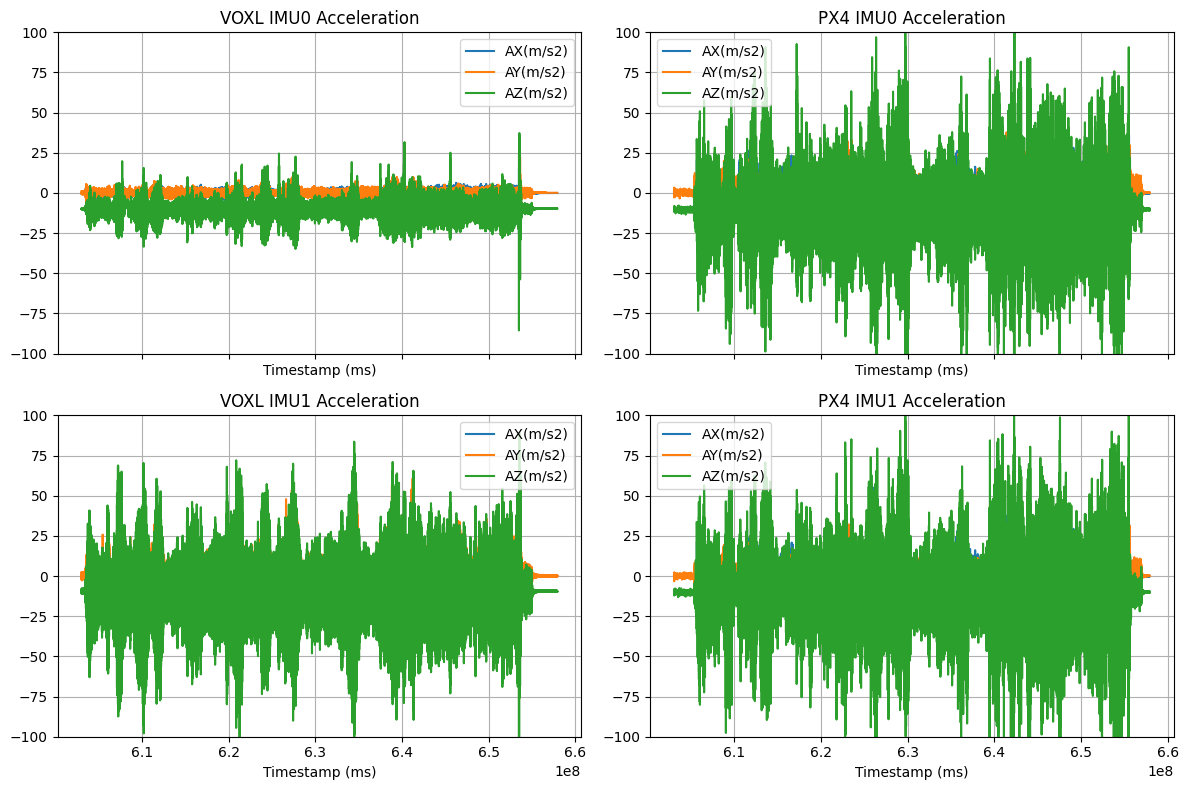

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axs[0, 0].plot(voxl_imu0['timestamp'], voxl_imu0[acc_col])
axs[0, 0].set_title('VOXL IMU0 Acceleration')
axs[0, 0].legend(acc_col)
axs[0, 0].set_xlabel('Timestamp (ms)')
axs[0, 0].grid()
axs[0, 0].set_ylim(-100, 100)


axs[1, 0].plot(voxl_imu1['timestamp'], voxl_imu1[acc_col])
axs[1, 0].set_title('VOXL IMU1 Acceleration')
axs[1, 0].legend(acc_col)
axs[1, 0].set_xlabel('Timestamp (ms)')
axs[1, 0].grid()
axs[1, 0].set_ylim(-100, 100)


axs[0, 1].plot(px4_imu0['timestamp'], px4_imu0[acc_col])
axs[0, 1].set_title('PX4 IMU0 Acceleration')
axs[0, 1].legend(acc_col)
axs[0, 1].set_xlabel('Timestamp (ms)')
axs[0, 1].grid()
axs[0, 1].set_ylim(-100, 100)

axs[1, 1].plot(px4_imu1['timestamp'], px4_imu1[acc_col])
axs[1, 1].set_title('PX4 IMU1 Acceleration')
axs[1, 1].legend(acc_col)
axs[1, 1].set_xlabel('Timestamp (ms)')
axs[1, 1].grid()
axs[1, 1].set_ylim(-100, 100)

plt.tight_layout()
plt.show()

### IMU Angular Velocity

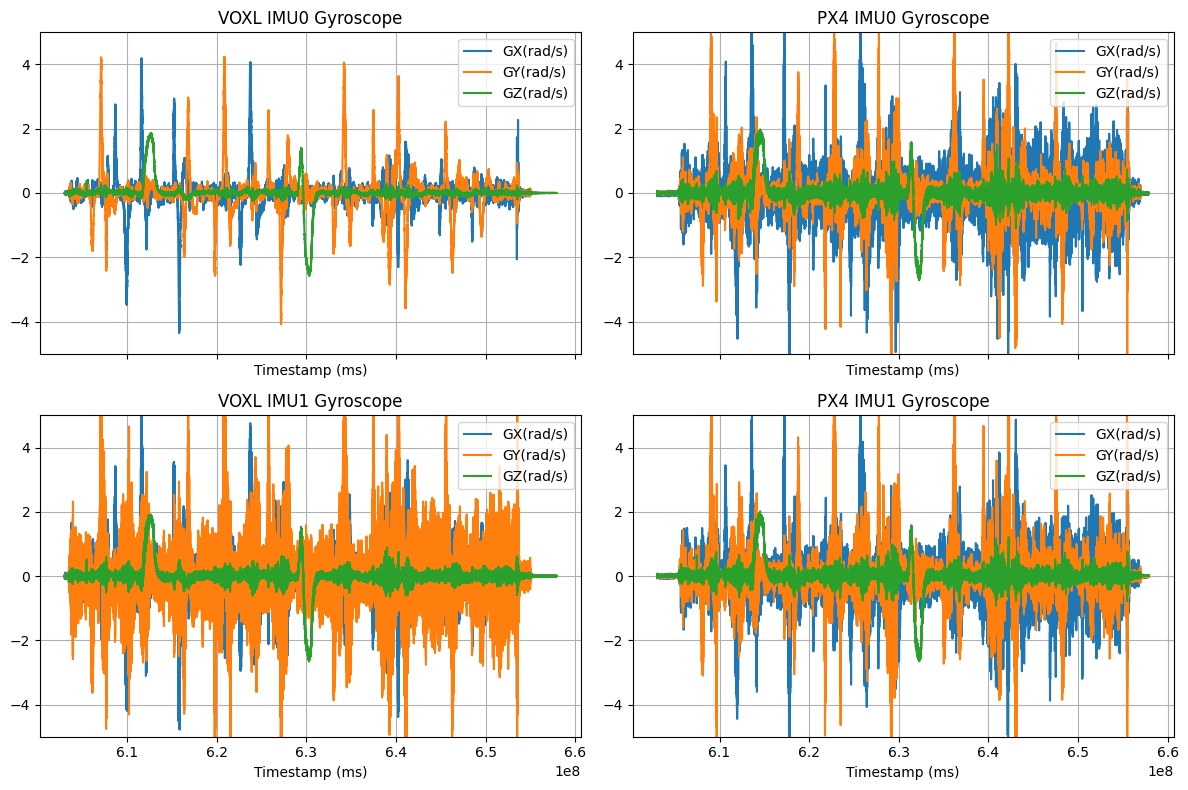

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axs[0, 0].plot(voxl_imu0['timestamp'], voxl_imu0[gyr_col])
axs[0, 0].set_title('VOXL IMU0 Gyroscope')
axs[0, 0].legend(gyr_col)
axs[0, 0].set_xlabel('Timestamp (ms)')
axs[0, 0].grid()
axs[0, 0].set_ylim(-5, 5)


axs[1, 0].plot(voxl_imu1['timestamp'], voxl_imu1[gyr_col])
axs[1, 0].set_title('VOXL IMU1 Gyroscope')
axs[1, 0].legend(gyr_col)
axs[1, 0].set_xlabel('Timestamp (ms)')
axs[1, 0].grid()
axs[1, 0].set_ylim(-5, 5)


axs[0, 1].plot(px4_imu0['timestamp'], px4_imu0[gyr_col])
axs[0, 1].set_title('PX4 IMU0 Gyroscope')
axs[0, 1].legend(gyr_col)
axs[0, 1].set_xlabel('Timestamp (ms)')
axs[0, 1].grid()
axs[0, 1].set_ylim(-5, 5)

axs[1, 1].plot(px4_imu1['timestamp'], px4_imu1[gyr_col])
axs[1, 1].set_title('PX4 IMU1 Gyroscope')
axs[1, 1].legend(gyr_col)
axs[1, 1].set_xlabel('Timestamp (ms)')
axs[1, 1].grid()
axs[1, 1].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

## Computer statistics

In [20]:
voxl_imu0.describe().loc[['mean', 'std']]

,AX(m/s2),AY(m/s2),AZ(m/s2),GX(rad/s),GY(rad/s),GZ(rad/s),T(C),timestamp
mean,-0.087421,0.096752,-10.110173,0.000761,0.004516,0.006096,52.951631,6.304798e+08
std,1.680320,1.743757,5.264125,0.542871,0.717146,0.369721,0.359575,1.583769e+07


In [21]:
voxl_imu1.describe().loc[['mean', 'std']]

,AX(m/s2),AY(m/s2),AZ(m/s2),GX(rad/s),GY(rad/s),GZ(rad/s),T(C),timestamp
mean,-0.292691,0.103904,-9.856050,0.004201,-0.000099,0.002531,35.860015,6.304791e+08
std,5.493182,8.374219,19.072831,0.730429,1.066292,0.380199,0.340457,1.583766e+07


In [22]:
px4_imu0.describe().loc[['mean', 'std']]

,timestamp,device_id,AX(m/s2),AY(m/s2),AZ(m/s2),GX(rad/s),GY(rad/s),GZ(rad/s),T(C)
mean,6.304637e+08,3670026.0,-0.107873,0.175156,-10.582675,-0.021661,0.006194,0.004957,42.214711
std,1.585231e+07,0.0,10.436099,8.557848,24.678348,0.902793,0.836563,0.401688,1.270639


In [23]:
px4_imu1.describe().loc[['mean', 'std']]

,timestamp,device_id,AX(m/s2),AY(m/s2),AZ(m/s2),GX(rad/s),GY(rad/s),GZ(rad/s),T(C)
mean,6.304465e+08,2490386.0,-0.110655,0.156289,-10.293926,-0.017553,-0.003206,0.019985,38.580826
std,1.585033e+07,0.0,10.770578,7.986667,26.109404,0.870151,0.897715,0.397823,0.995761


VOXL IMU_0 has less std than the others. So, VOXL IMU_0 is the good IMU candidate for the further process.

## Testing EKF for attitude estimation

In [83]:
delta_time = voxl_imu0['timestamp'].diff().fillna(0) / 1_000_000
g = np.array([0, 0, 9.81])


In [115]:

pos = []
vel = []
quat = []
_q = R.from_euler('xyz', [0., 0., 0.], degrees=False).as_quat()
_pos = np.array([0.0, 0.0, 0.0])
_vel = np.array([0.0, 0.0, 0.0])


ekf = EKF(frequency=1000, q0=np.array([1., 0., 0., 0.]), frame='ENU')


pos.append(_pos.copy())
vel.append(_vel.copy())
quat.append(_q.copy())

sigma_acc = 6.9e-04
sigma_gyro = 4.9e-05
acc_noise = np.random.normal(0, sigma_acc, 3)
gyro_noise = np.random.normal(0, sigma_gyro, 3)

for i in tqdm(range(1, len(voxl_imu0))):

    _dt = delta_time.iloc[i]
    acc_noise += np.random.normal(0, sigma_acc, 3)
    gyro_noise += np.random.normal(0, sigma_gyro, 3)
    acc = voxl_imu0[acc_col].iloc[i].to_numpy()
    gyr = voxl_imu0[gyr_col].iloc[i].to_numpy()

    _acc = acc + acc_noise
    _gyr = gyr + gyro_noise

    q = np.array([_q[3], _q[0], _q[1], _q[2]]).copy()

    q = ekf.update(q, _gyr, _acc)

    _q = np.array([q[1], q[2], q[3], q[0]]).copy()
    _R = R.from_quat(_q).as_matrix()

    _pos += _vel * _dt
    _vel += (_R @ _acc + g) * _dt


    pos.append(_pos.copy())
    vel.append(_vel.copy())
    quat.append(_q.copy())

quat = np.array(quat)
pos = np.array(pos)
vel = np.array(vel)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 55366/55366 [00:29<00:00, 1908.15it/s]


In [116]:
estimated_angle = R.from_quat(quat).as_euler('zyx', degrees=False)

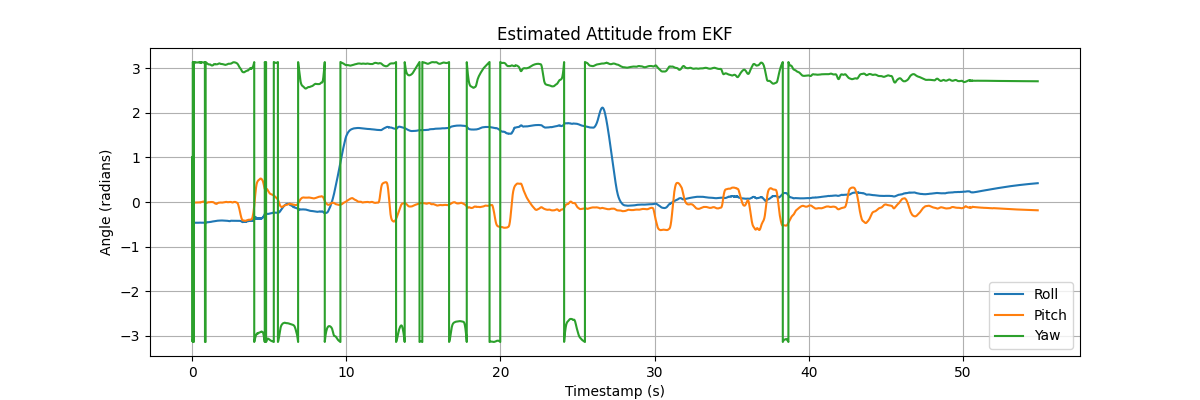

In [117]:
plt.figure(figsize=(12, 4))
plt.plot(delta_time.cumsum(), estimated_angle)
plt.title('Estimated Attitude from EKF')
plt.legend(['Roll', 'Pitch', 'Yaw'])
plt.xlabel('Timestamp (s)')
plt.ylabel('Angle (radians)')
plt.grid()
plt.show()

In [118]:
plt.close()

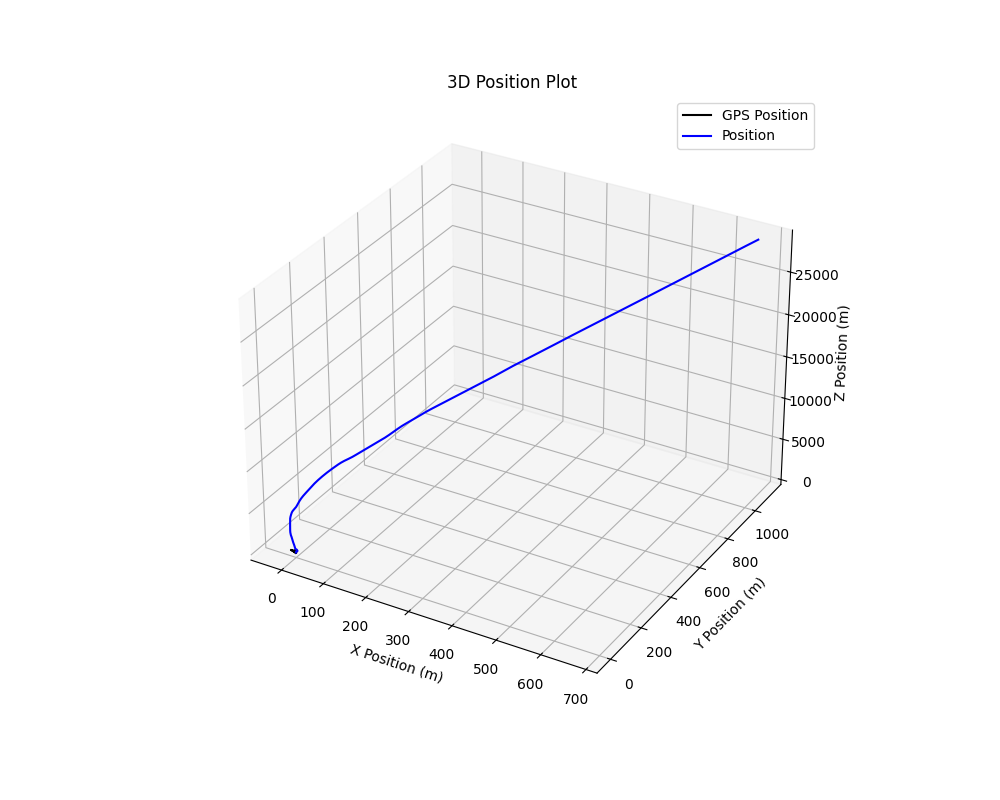

In [119]:
%matplotlib widget

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(gps_data[:, 0], gps_data[:, 1], gps_data[:, 2], label='GPS Position', color="black")
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], label='Position', color="blue")
ax.set_title('3D Position Plot')
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Z Position (m)')
ax.legend()
ax.grid()

plt.show()

In [120]:
plt.close()